In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
import astropy.units as u
from astropy.io import fits
from pathlib import Path
from IPython.display import clear_output
from importlib import reload
import ray
import os

import poppy
import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

import esc_fresnel
import esc_fresnel.utils as utils
from esc_fresnel.math_module import xp, xcipy, ensure_np_array
from esc_fresnel.imshows import imshow1, imshow2, imshow3, imshow
import esc_fresnel.esc_fresnel as esc
import esc_fresnel.esc_optics as esc_optics


# Create an instance of the Fresnel model and check some of the parameters used in the propagation code. 

1


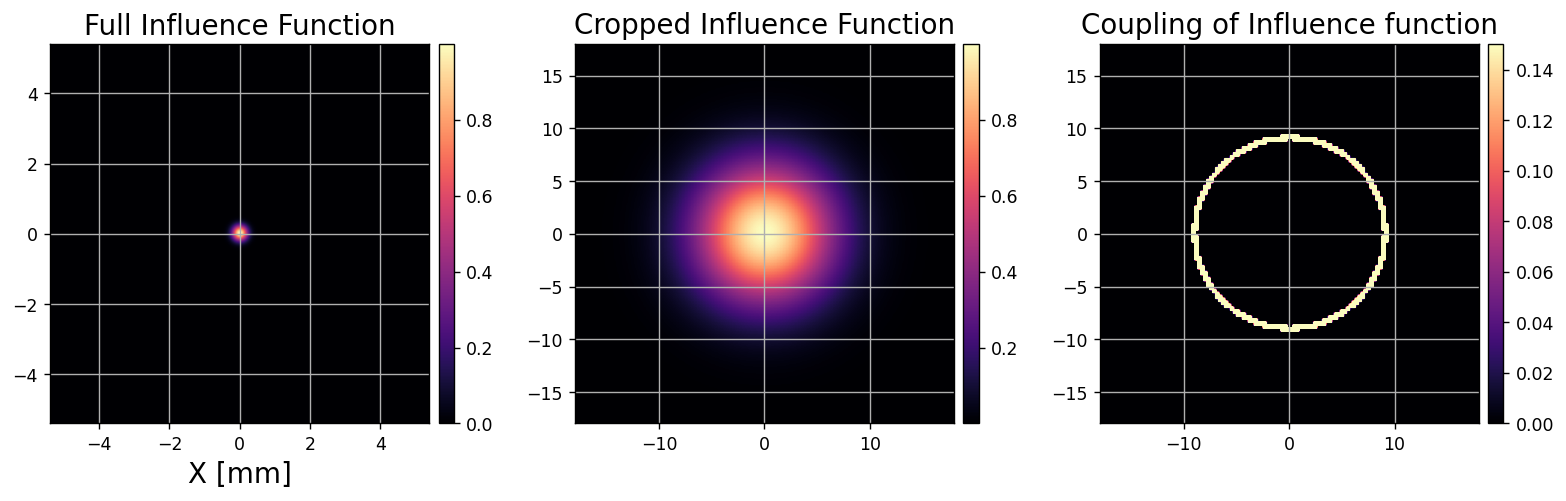

In [7]:
reload(esc)
M = esc.single()

inf_fun_coupling_region = (0.15-0.01<M.DM.inf_fun) & (M.DM.inf_fun<0.15+0.01)

imshow(
    [M.DM.inf_fun, M.DM.inf_fun, inf_fun_coupling_region],
    titles=['Full Influence Function', 'Cropped Influence Function', 'Coupling of Influence function'],
    xlabels=['X [mm]'],
    title_fzs=[16]*3,
    label_fzs=[16]*3,
    pxscls=[M.DM.pixelscale.to_value(u.mm/u.pix), 1/M.DM.inf_sampling, 1/M.DM.inf_sampling],
    cmaps=['magma']*3,
    grids=[1]*3,
    norms=[None, None, Normalize(vmax=0.15)],
    npix=[None, int(np.round(4*M.DM.inf_sampling)), int(np.round(4*M.DM.inf_sampling))],
    wspace=0.3,
)

# Compute the focal plane image with and without the vortex.

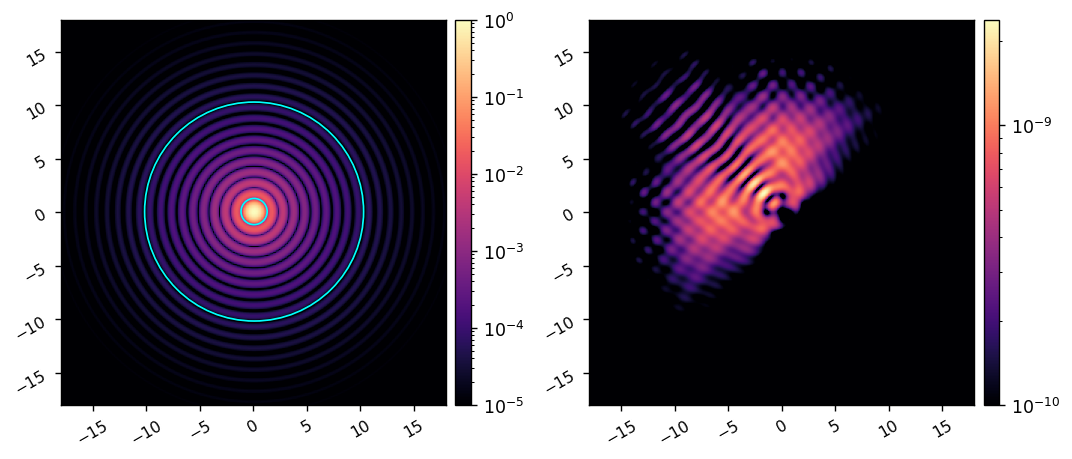

In [6]:
reload(esc)

# poppy_log.disabled = False
poppy_log.disabled = True

M = esc.single(
    npix=1000, 
    oversample=4.096, 
    npsf=256,
)
ref_psf = M.snap()

M.Imax_ref = xp.max(ref_psf)
M.use_vortex = True
ref_coro_im = M.snap()

psf_center = (M.psf_pixelscale_lamD/2, M.psf_pixelscale_lamD/2)
imshow2(ref_psf/M.Imax_ref, ref_coro_im, lognorm=True, vmin1=1e-5, vmin2=1e-10, 
        npix=M.npsf, pxscl=M.psf_pixelscale_lamD, 
        patches1=[Circle(psf_center, 1.22, fill=False, color='cyan'), Circle(psf_center, 10.22, fill=False, color='cyan')])

# Perform an initial propagation to compute a reference PSF that is used to normalize the coronagraphic images. 

In [11]:
wfe_path = Path('/npool/nvme/kianmilani/esc-wfe-maps')
inter = poppy.poppy_core.PlaneType.intermediate

wfes = {
    'm1':poppy.FITSOpticalElement(name='m1_wfe', opd=str(wfe_path/'m1_subap.fits'), opdunits='nanometers', planetype=inter), 
    'm2':poppy.FITSOpticalElement(name='m2_wfe', opd=str(wfe_path/'m2_subap.fits'), opdunits='nanometers', planetype=inter), 
    'm3':poppy.FITSOpticalElement(name='m3_wfe', opd=str(wfe_path/'m3_subap.fits'), opdunits='nanometers', planetype=inter), 
    'm4':poppy.FITSOpticalElement(name='m4_wfe', opd=str(wfe_path/'m4_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap1':poppy.FITSOpticalElement(name='oap1_wfe', opd=str(wfe_path/'oap1_subap.fits'), opdunits='nanometers', planetype=inter), 
    'fm1':poppy.FITSOpticalElement(name='fm1_wfe', opd=str(wfe_path/'fm1_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap2':poppy.FITSOpticalElement(name='oap2_wfe', opd=str(wfe_path/'oap2_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap3':poppy.FITSOpticalElement(name='oap3_wfe', opd=str(wfe_path/'oap3_subap.fits'), opdunits='nanometers', planetype=inter), 
    'fsm':poppy.FITSOpticalElement(name='fsm_wfe', opd=str(wfe_path/'fsm_subap.fits'), opdunits='nanometers', planetype=inter), 
    'fm2':poppy.FITSOpticalElement(name='fm2_wfe', opd=str(wfe_path/'fm2_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap4':poppy.FITSOpticalElement(name='oap4_wfe', opd=str(wfe_path/'oap4_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap5':poppy.FITSOpticalElement(name='oap5_wfe', opd=str(wfe_path/'oap5_subap.fits'), opdunits='nanometers', planetype=inter), 
    'input_lp':poppy.FITSOpticalElement(name='input_lp_wfe', opd=str(wfe_path/'input_lp_subap.fits'), opdunits='nanometers', planetype=inter), 
    'input_qwp':poppy.FITSOpticalElement(name='input_qwp_wfe', opd=str(wfe_path/'input_qwp_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap6':poppy.FITSOpticalElement(name='oap6_wfe', opd=str(wfe_path/'oap6_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap7':poppy.FITSOpticalElement(name='oap7_wfe', opd=str(wfe_path/'oap7_subap.fits'), opdunits='nanometers', planetype=inter),  
    'oap9':poppy.FITSOpticalElement(name='oap9_wfe', opd=str(wfe_path/'oap9_subap.fits'), opdunits='nanometers', planetype=inter), 
    'collimator':poppy.FITSOpticalElement(name='collimator_wfe', opd=str(wfe_path/'collimator_subap.fits'), opdunits='nanometers', planetype=inter), 
    'filter':poppy.FITSOpticalElement(name='filter_wfe', opd=str(wfe_path/'filter_subap.fits'), opdunits='nanometers', planetype=inter), 
    'output_qwp':poppy.FITSOpticalElement(name='output_qwp_wfe', opd=str(wfe_path/'output_qwp_subap.fits'), opdunits='nanometers', planetype=inter), 
    'output_lp':poppy.FITSOpticalElement(name='output_lp_wfe', opd=str(wfe_path/'output_lp_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap10':poppy.FITSOpticalElement(name='oap10_wfe', opd=str(wfe_path/'oap10_subap.fits'), opdunits='nanometers', planetype=inter), 
}

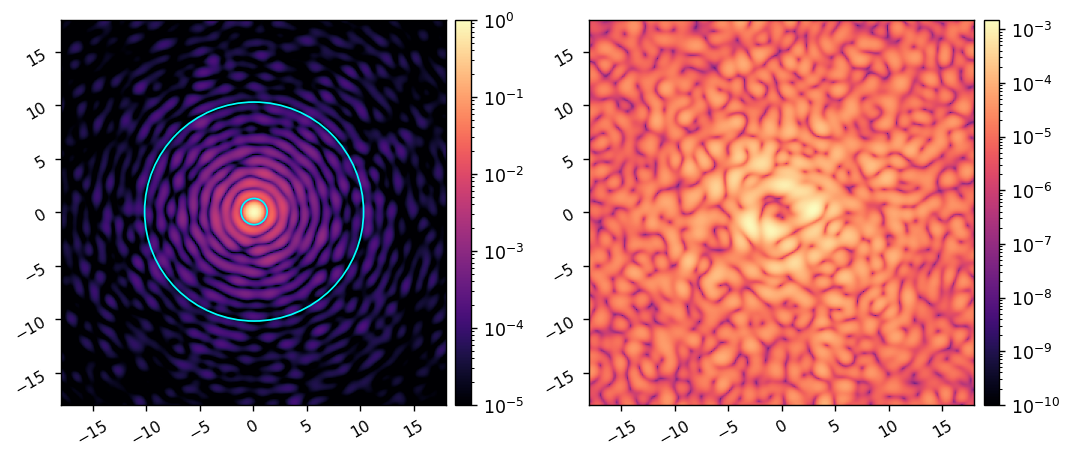

In [12]:
reload(esc)
# reload(esc_optics)

poppy_log.disabled = True

M = esc.single(
    npix=1000, 
    oversample=4.096, 
    npsf=256,
)

M.wfes = wfes
M.wavelength = 650e-9*u.m

ref_psf = M.snap()

M.Imax_ref = xp.max(ref_psf)
M.use_vortex = True
ref_coro_im = M.snap()

psf_center = (M.psf_pixelscale_lamD/2, M.psf_pixelscale_lamD/2)
imshow2(
    ref_psf/M.Imax_ref, ref_coro_im, 
    lognorm=True,
    vmin1=1e-5, vmin2=1e-10, 
    npix=M.npsf, 
    pxscl=M.psf_pixelscale_lamD, 
    patches1=[Circle(psf_center, 1.22, fill=False, color='cyan'), Circle(psf_center, 10.22, fill=False, color='cyan')],
)

In [9]:
poppy_log.disabled = False

im = M.snap()

INFO:poppy:Initialized OpticalSystem: ESC to FPM
INFO:poppy:Added optic: Entrance Pupil (subaperture) after separation: 0.00e+00 m 
INFO:poppy:Added optic: m1 after separation: 0.00e+00 m 
INFO:poppy:Added optic: m1_wfe after separation: 0.00e+00 m 
INFO:poppy:Added optic: m2 after separation: 7.50e+03 mm 
INFO:poppy:Added optic: m2_wfe after separation: 0.00e+00 m 
INFO:poppy:Added optic: m3 after separation: 7.44e+03 mm 
INFO:poppy:Added optic: m3_wfe after separation: 0.00e+00 m 
INFO:poppy:Added optic: m4 (pupil) after separation: 1.05e+03 mm 
INFO:poppy:Added optic: m4_wfe after separation: 0.00e+00 m 
INFO:poppy:Added optic: WCC_FP after separation: 1.27e+03 mm 
INFO:poppy:Added optic: oap1 after separation: 5.11e+02 mm 
INFO:poppy:Added optic: oap1_wfe after separation: 0.00e+00 m 
INFO:poppy:Added optic: fm1 after separation: 1.91e+02 mm 
INFO:poppy:Added optic: fm1_wfe after separation: 0.00e+00 m 
INFO:poppy:Added optic: Pupil Mask after separation: 5.17e+02 mm 
INFO:poppy:Ad

# Use ESC fresnel model to compute the wavefront at each plane and visualize the various pupil and focal planes.

Note that this is very memory intesive and is only meant to be used for understanding and debugging the Fresnel model. Standard propagations should only use calc_wf() or snap() methods, not calc_wfs(). 

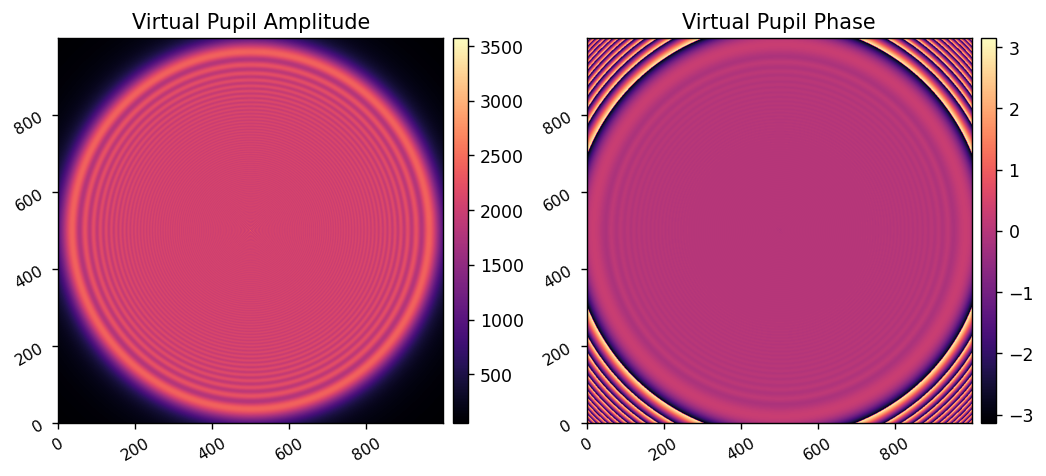

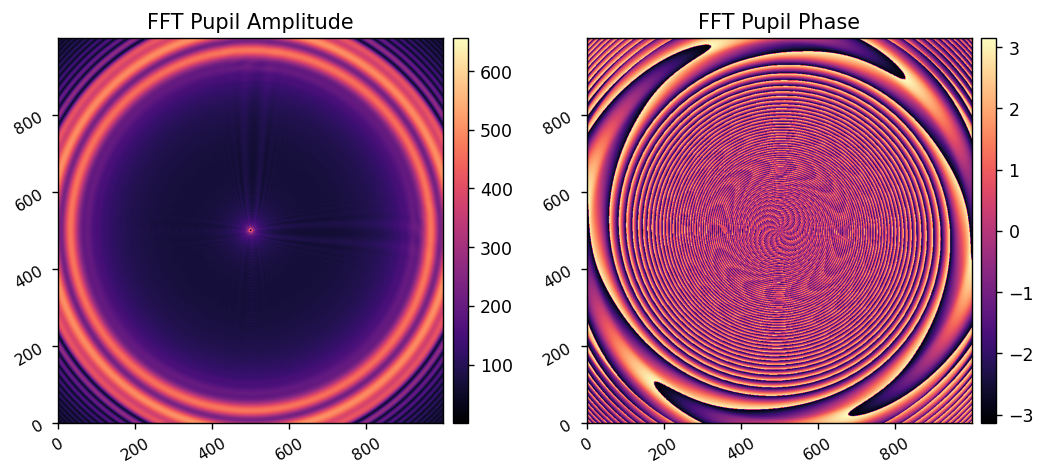

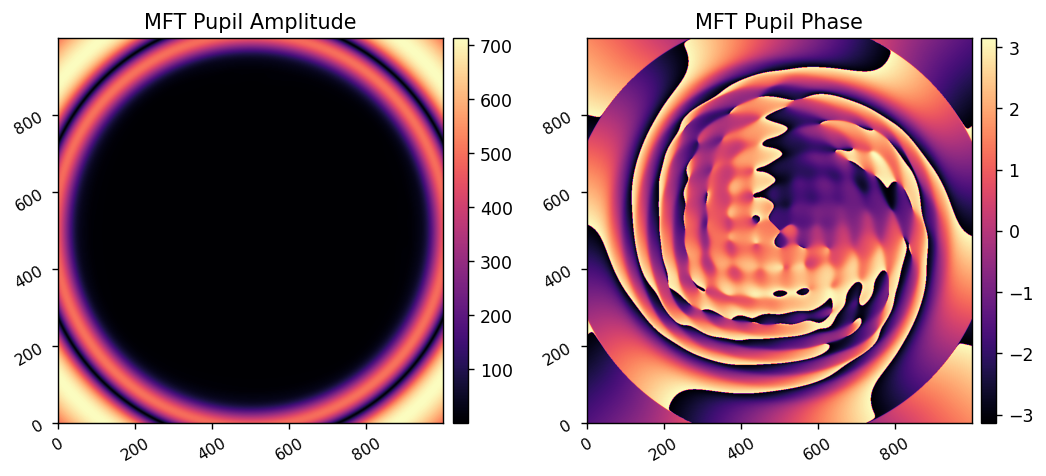

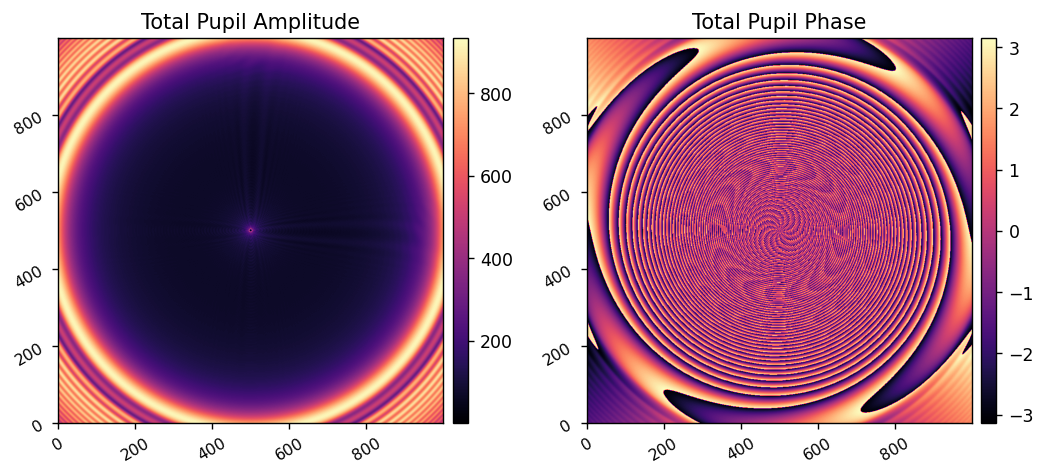

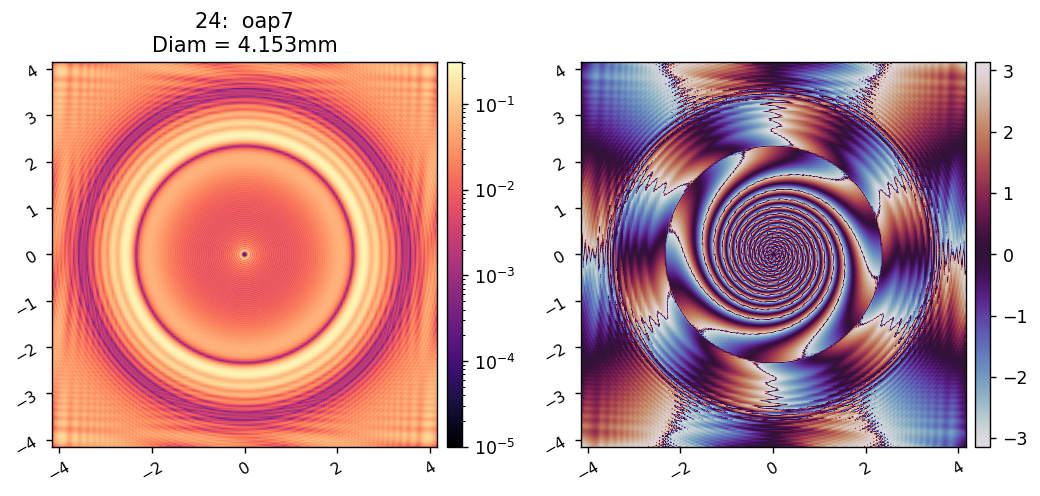

In [8]:
reload(esc)

poppy_log.disabled = True

M = esc.single(
    npix=1000, 
    oversample=2.048,
)
M.use_vortex = True
M.plot_vortex = True # this will display the intermediate steps while propagating through the vortex

wfs = M.calc_wfs()

i = 24 # Lyot
wf = wfs[i]
imshow2(
    wf.intensity, wf.phase, 
    f'{i:d}: '+wf.location[5:] + f'\nDiam = {2*wf.spot_radius().to_value(u.mm):.3f}mm', 
    pxscl=wf.pixelscale.to(u.mm/u.pix), npix=2*M.npix, cmap2='twilight',
    lognorm1=True, vmin1=1e-5,
#     vmin2=-0.01, vmax2=0.01,
)

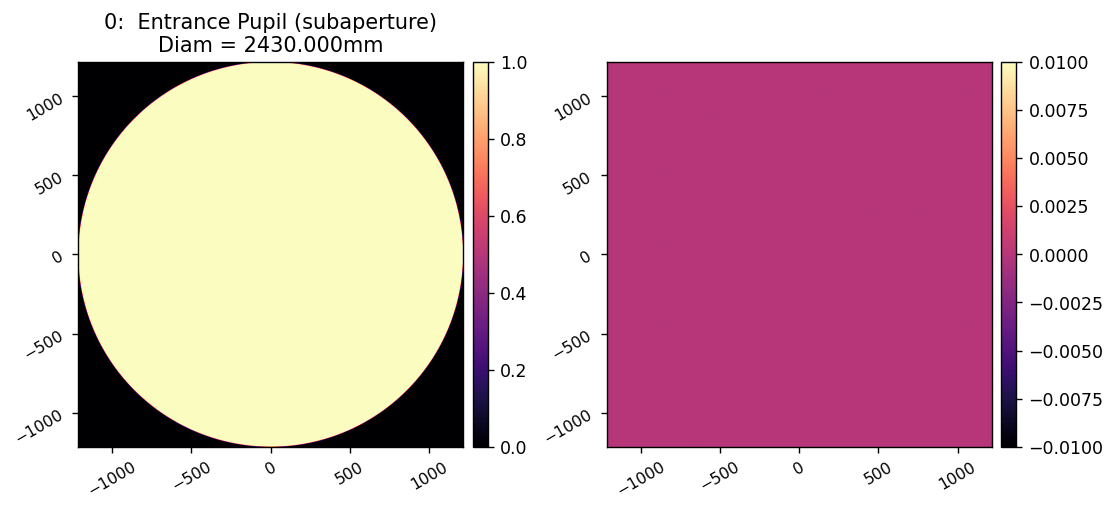

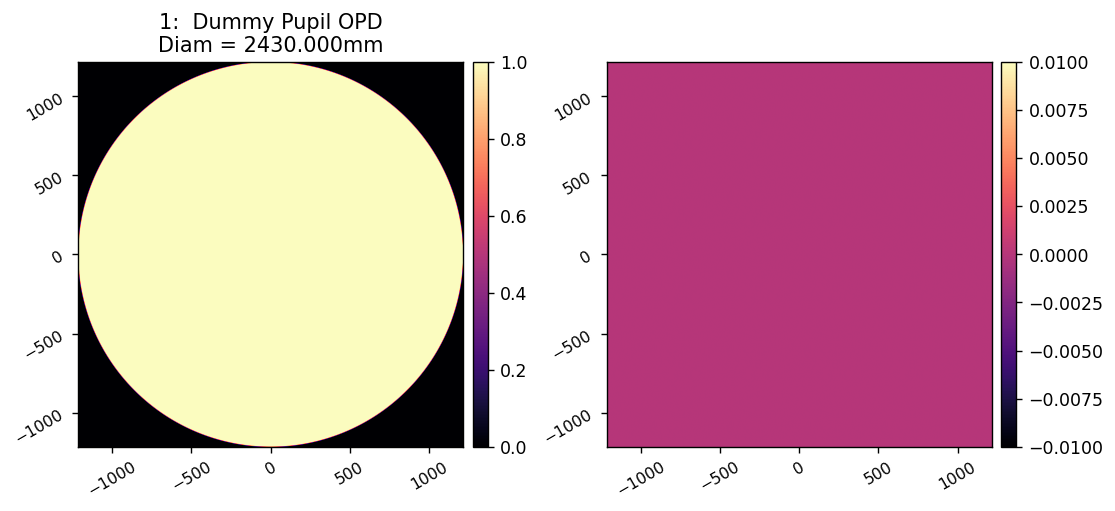

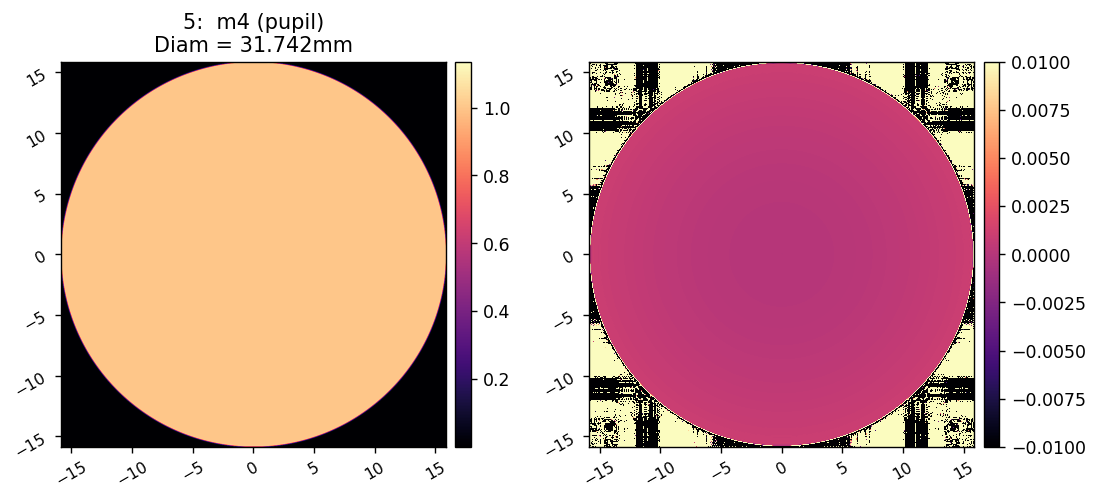

Focal Plane Correction:  0.0 mm


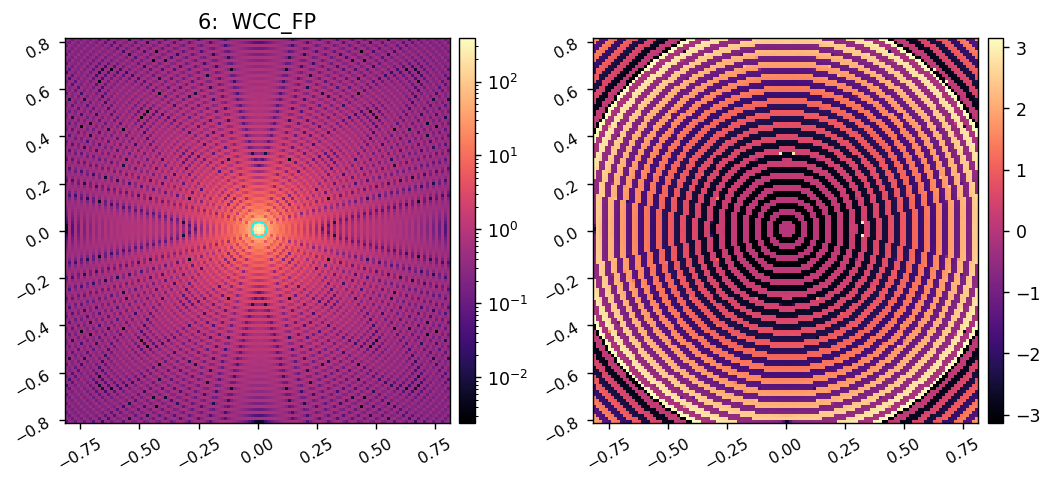

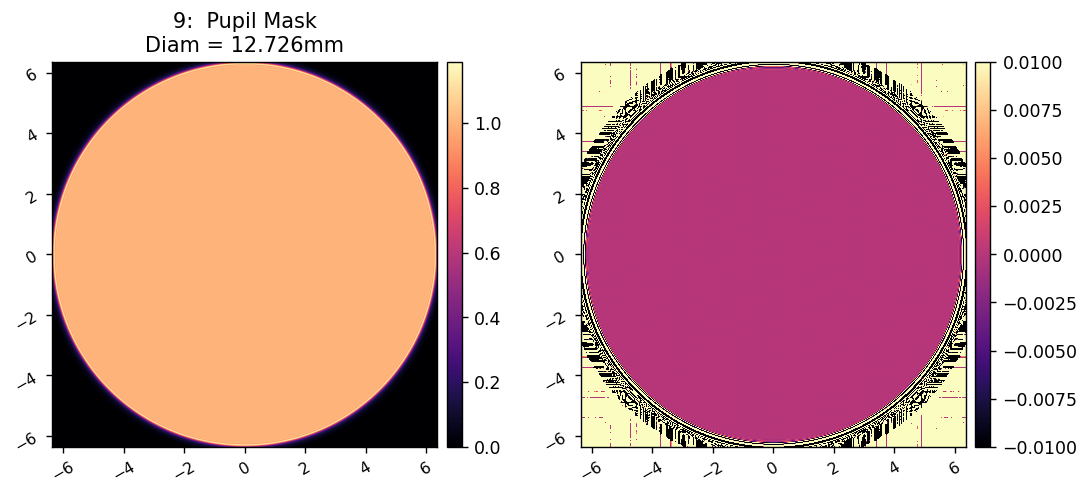

Focal Plane Correction:  0.0 mm


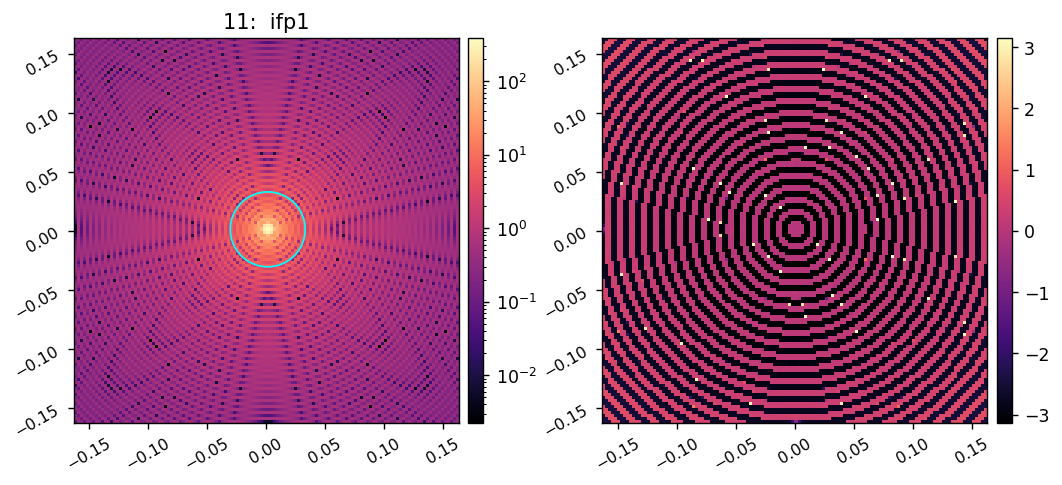

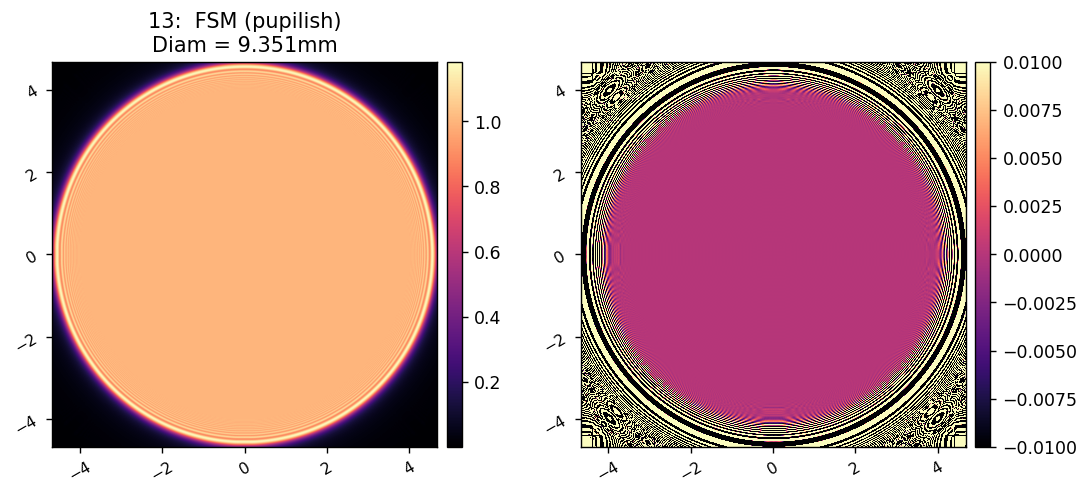

Focal Plane Correction:  0.0 mm


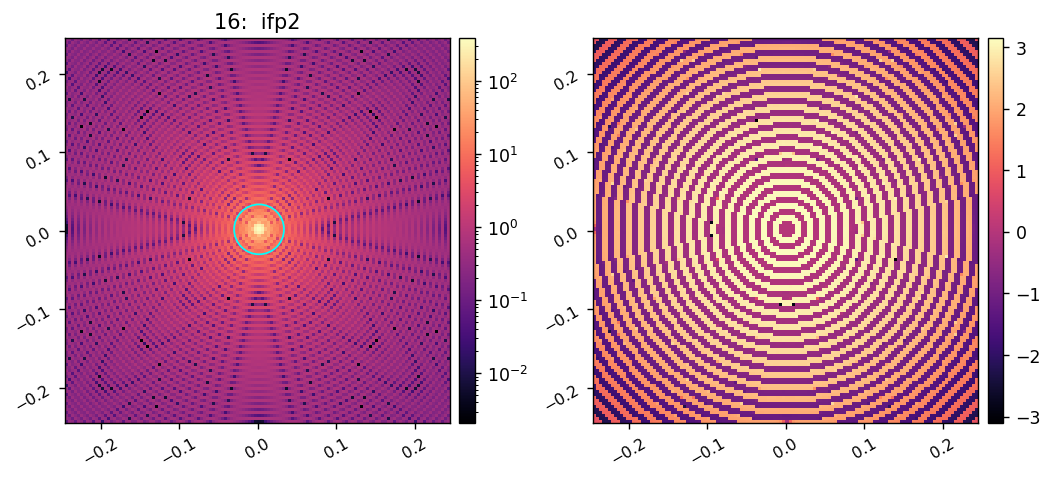

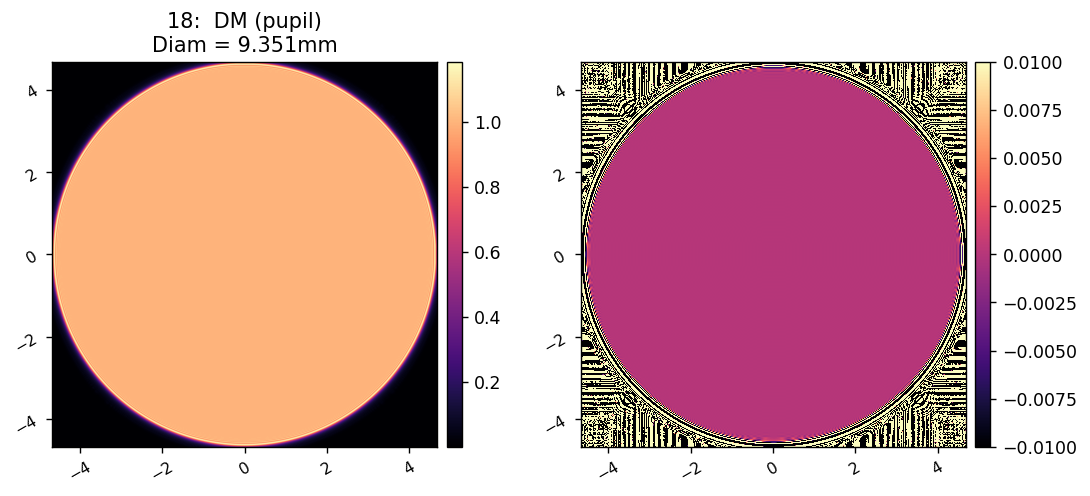

Focal Plane Correction:  -1541.0562467009754 mm


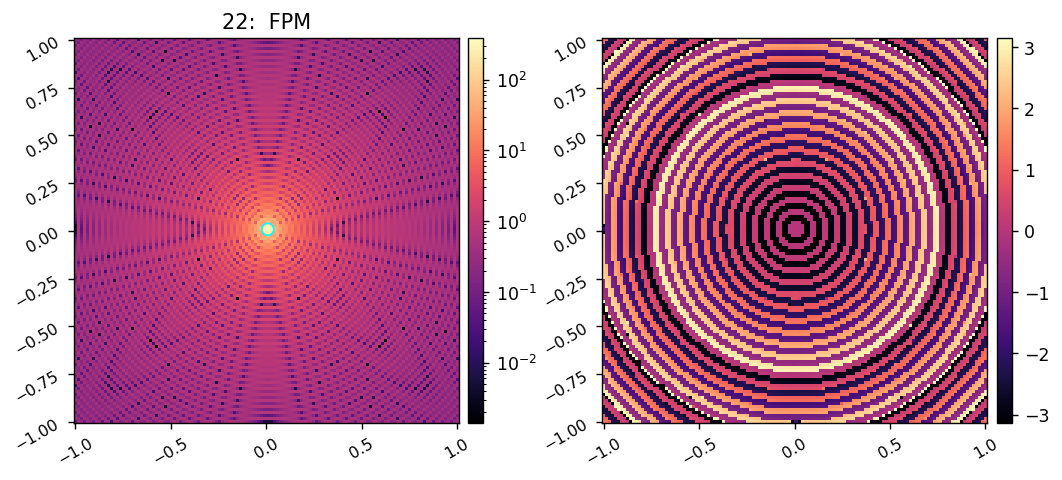

Focal Plane Correction:  0.0 mm


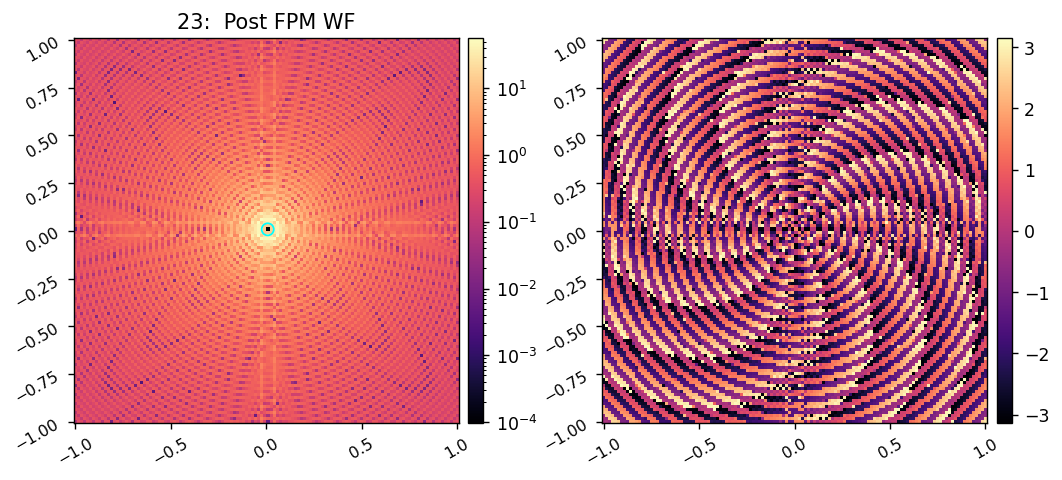

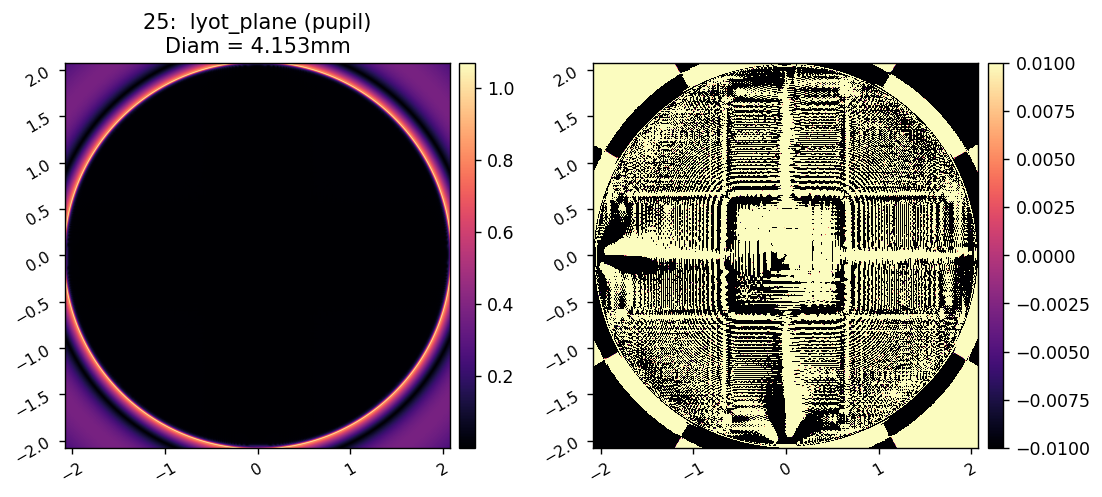

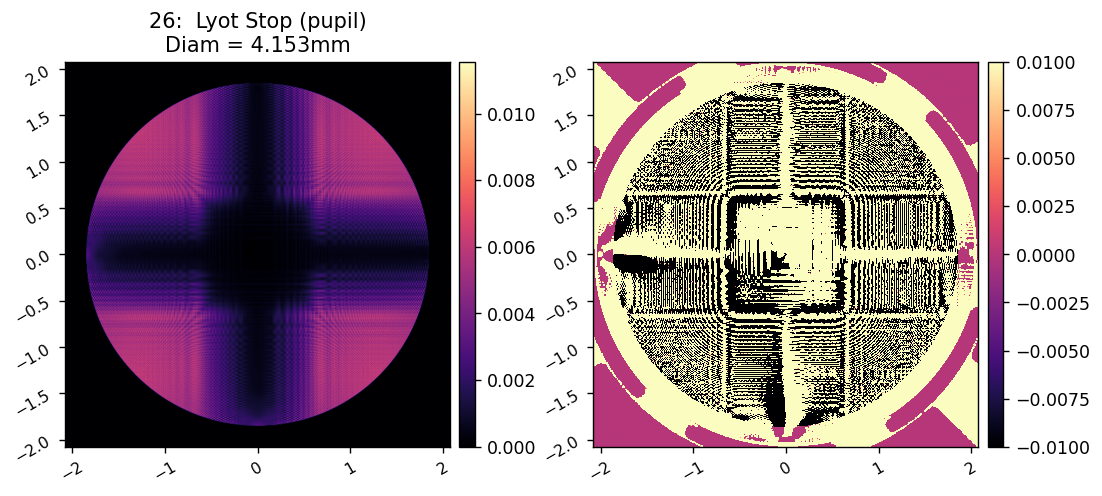

Focal Plane Correction:  0.0 mm


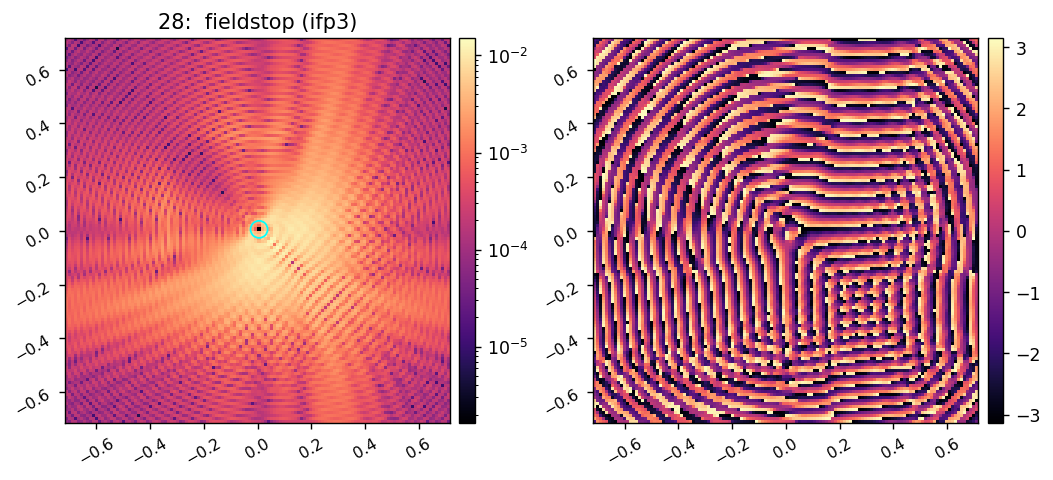

Focal Plane Correction:  0.0 mm


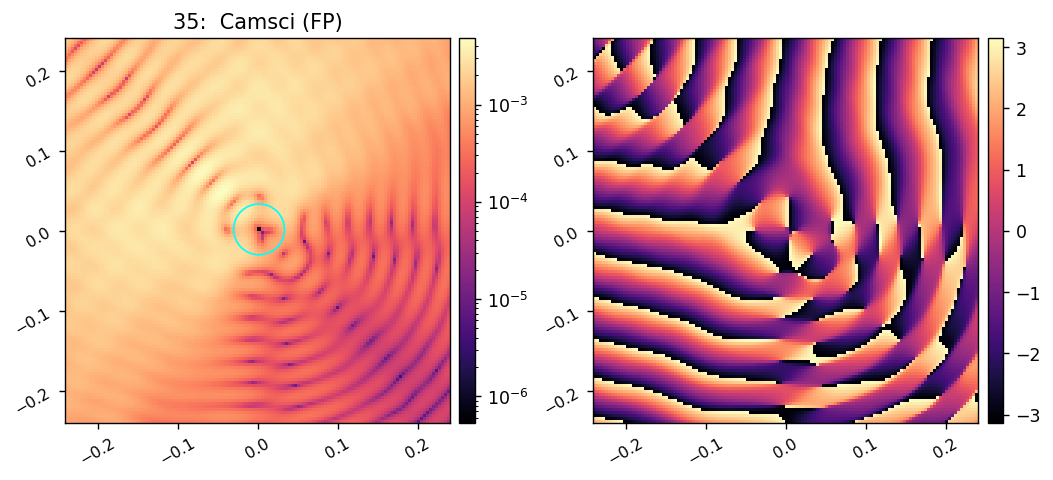

In [9]:
for i,wf in enumerate(wfs):
    if 'fp' in wf.location.lower():
        f_corr = wf.z_w0 - wf.z
        print('Focal Plane Correction: ', f_corr.to(u.mm))
        pxscl_mm = wf.pixelscale.to_value(u.mm/u.pix)
        airy_rad = 31.752*u.um
        imshow2(
            wf.amplitude, wf.phase, 
            f'{i:d}: '+wf.location[5:], 
            pxscl=pxscl_mm, 
            npix=128, 
            lognorm1=True,
            patches1=[Circle((pxscl_mm/2, pxscl_mm/2), airy_rad.to_value(u.mm), color='cyan', fill=False)]
        )
    elif 'pupil' in wf.location.lower():
        imshow2(
            wf.amplitude, wf.phase, 
            f'{i:d}: '+wf.location[5:] + f'\nDiam = {2*wf.spot_radius().to_value(u.mm):.3f}mm', 
            pxscl=wf.pixelscale.to(u.mm/u.pix), 
            npix=M.npix, 
            vmin2=-0.01, vmax2=0.01,
        )

# Use the esc_fresnel.multi() class in order to do parallelized propagations to simulate a broadband image. This requires the Ray package to perform the parallelization. 

In [2]:
reload(esc)
ray_esc = ray.remote(esc.single)

N_waves = 5
bw = 0.1
wavelength_c = 650*u.nm
waves = np.linspace(wavelength_c*(1 - bw/2), wavelength_c*(1 + bw/2), N_waves)
print(waves)

[617.5  633.75 650.   666.25 682.5 ] nm


In [3]:
actors = []
for i in range(N_waves):
    params = {
        'wavelength':waves[i],
    }
    actors.append(ray_esc.options(num_cpus=1, num_gpus=1/8).remote(**params))


/home/kianmilani/miniconda3/envs/gpu311env/lib/python3.11/subprocess.py:1885: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(
/home/kianmilani/miniconda3/envs/gpu311env/lib/python3.11/subprocess.py:1885: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(
2024-09-12 11:11:02,022	INFO worker.py:1636 -- Started a local Ray instance.


(single pid=3406923) Oversampling > 2x suggested for reliable results in Fresnel propagation.


In [ ]:
import os
from pathlib import Path
wfe_path = Path(os.path.dirname(esc_fresnel.__file__))/'wfe-maps'

inter = poppy.poppy_core.PlaneType.intermediate

wfes = {
    'm1':poppy.FITSOpticalElement(name='m1_wfe', opd=str(wfe_path/'m1_subap.fits'), opdunits='nanometers', planetype=inter), 
    'm2':poppy.FITSOpticalElement(name='m2_wfe', opd=str(wfe_path/'m2_subap.fits'), opdunits='nanometers', planetype=inter), 
    'm3':poppy.FITSOpticalElement(name='m3_wfe', opd=str(wfe_path/'m3_subap.fits'), opdunits='nanometers', planetype=inter), 
    'm4':poppy.FITSOpticalElement(name='m4_wfe', opd=str(wfe_path/'m4_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap1':poppy.FITSOpticalElement(name='oap1_wfe', opd=str(wfe_path/'oap1_subap.fits'), opdunits='nanometers', planetype=inter), 
    'fm1':poppy.FITSOpticalElement(name='fm1_wfe', opd=str(wfe_path/'fm1_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap2':poppy.FITSOpticalElement(name='oap2_wfe', opd=str(wfe_path/'oap2_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap3':poppy.FITSOpticalElement(name='oap3_wfe', opd=str(wfe_path/'oap3_subap.fits'), opdunits='nanometers', planetype=inter), 
    'fsm':poppy.FITSOpticalElement(name='fsm_wfe', opd=str(wfe_path/'fsm_subap.fits'), opdunits='nanometers', planetype=inter), 
    'fm2':poppy.FITSOpticalElement(name='fm2_wfe', opd=str(wfe_path/'fm2_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap4':poppy.FITSOpticalElement(name='oap4_wfe', opd=str(wfe_path/'oap4_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap5':poppy.FITSOpticalElement(name='oap5_wfe', opd=str(wfe_path/'oap5_subap.fits'), opdunits='nanometers', planetype=inter), 
    'input_lp':poppy.FITSOpticalElement(name='input_lp_wfe', opd=str(wfe_path/'input_lp_subap.fits'), opdunits='nanometers', planetype=inter), 
    'input_qwp':poppy.FITSOpticalElement(name='input_qwp_wfe', opd=str(wfe_path/'input_qwp_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap6':poppy.FITSOpticalElement(name='oap6_wfe', opd=str(wfe_path/'oap6_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap7':poppy.FITSOpticalElement(name='oap7_wfe', opd=str(wfe_path/'oap7_subap.fits'), opdunits='nanometers', planetype=inter), 
    # 'oap8_locam':poppy.FITSOpticalElement(name='oap8_wfe', opd=str(wfe_path/'oap8_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap9':poppy.FITSOpticalElement(name='oap9_wfe', opd=str(wfe_path/'oap9_subap.fits'), opdunits='nanometers', planetype=inter), 
    'collimator':poppy.FITSOpticalElement(name='collimator_wfe', opd=str(wfe_path/'collimator_subap.fits'), opdunits='nanometers', planetype=inter), 
    'filter':poppy.FITSOpticalElement(name='filter_wfe', opd=str(wfe_path/'filter_subap.fits'), opdunits='nanometers', planetype=inter), 
    'output_qwp':poppy.FITSOpticalElement(name='output_qwp_wfe', opd=str(wfe_path/'output_qwp_subap.fits'), opdunits='nanometers', planetype=inter), 
    'output_lp':poppy.FITSOpticalElement(name='output_lp_wfe', opd=str(wfe_path/'output_lp_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap10':poppy.FITSOpticalElement(name='oap10_wfe', opd=str(wfe_path/'oap10_subap.fits'), opdunits='nanometers', planetype=inter), 
}

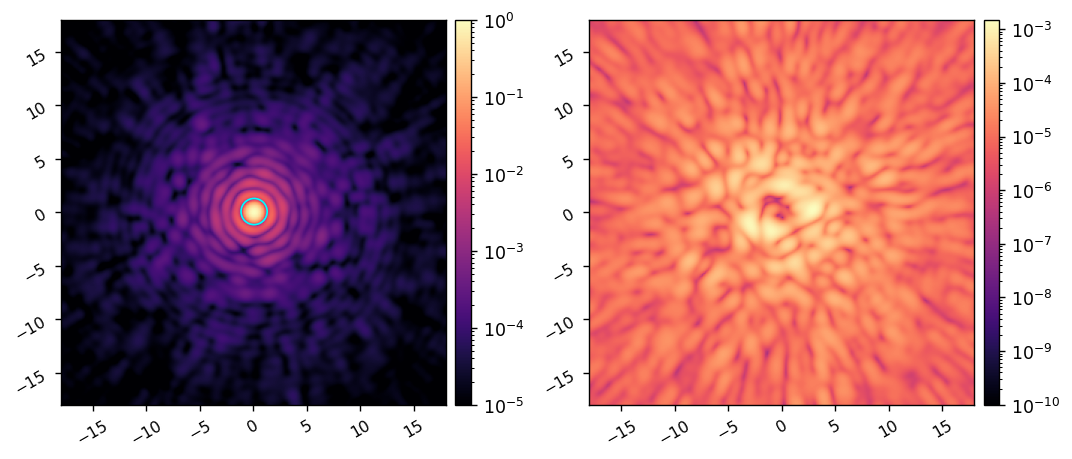

In [6]:
reload(esc)
M = esc.multi(actors)
M.set_actor_attr('wfes', wfes)

M.set_actor_attr('use_vortex', False)
ref_psf = M.snap()
M.Imax_ref = xp.max(ref_psf)

M.set_actor_attr('use_vortex', True)
ref_coro_im = M.snap()

psf_center = (M.psf_pixelscale_lamD/2, M.psf_pixelscale_lamD/2)
imshow2(ref_psf/M.Imax_ref, ref_coro_im, lognorm=True, vmin1=1e-5, vmin2=1e-10, 
        npix=M.npsf, pxscl=M.psf_pixelscale_lamD, 
        patches1=[Circle(psf_center, 1.22, fill=False, color='cyan')])